# TS5

#### Rey Tomás 
#### APS

# Introducción

En este trabajo se procesarán y analizarán tres señales distintas: Una señal de audio, un registro de un Electrocardiograma y una señal de pletismografia (ppg). Se estimará la potencia espectral de cada una haciendo uso del método de Welch y probando distintas divisiones del espacio muestral hasta encontrar el balance entre precisión y varianza que permita ver la señal de manera nítida. Se utilizará la ventana blackman harris ya que tiene una gran capacidad de atenuar lóbulos laterales para así evitar fugas espectrales cuando se usen ventanas con subdivisiones de tiempo más cortas.

A partir de los espectros resultantes, se aplicará el criterio del 95% de la energia acumulada para determinar a qué frecuencia se encuentra el ancho de banda

In [2]:

import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio
from scipy.io.wavfile import write



# Archivo de audio "La cucaracha"

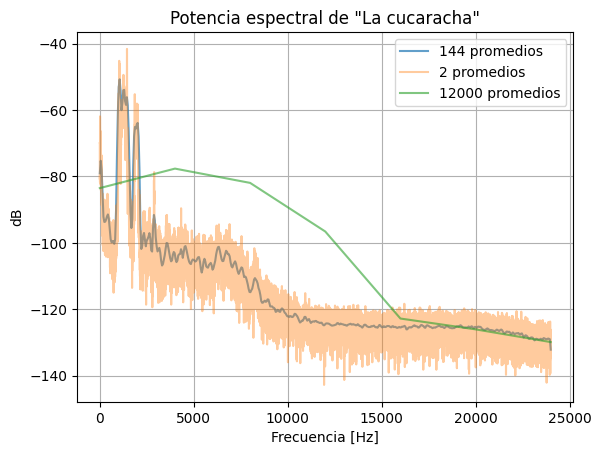

In [3]:
# Cargar el archivo CSV como un array de NumPy
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')
#fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')
#fs_audio, wav_data = sio.wavfile.read('silbido.wav')

nperseg=1000

f,Pxx=sig.welch(wav_data,fs_audio,window='blackmanharris',nperseg=nperseg)
f2,Pxx2=sig.welch(wav_data,fs_audio,window='blackmanharris',nperseg=len(wav_data)/2)
f3,Pxx3=sig.welch(wav_data,fs_audio,window='blackmanharris',nperseg=12)


plt.figure()
plt.plot(f,10*np.log10(Pxx),label='144 promedios',alpha=0.7)
plt.plot(f2,10*np.log10(Pxx2),label='2 promedios',alpha=0.4)
plt.plot(f3,10*np.log10(Pxx3),label='12000 promedios',alpha=0.6)

plt.grid(True)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('dB')
plt.title('Potencia espectral de "La cucaracha"')
plt.legend()
plt.show()

Este gráfico muestra como se distribuye la energía acústica durante el silbido de la melodía "la cucaracha". La mayor parte de la potencia se ve concentrada a bajas frecuencias. En este gráfico se ve como para un número bajo de promedios la señal en varios puntos queda tapada por el ruido, mientras que para muchos promedios la señal se ensancha y aplana, perdiendo y tapando la mayor parte de la información. En un punto medio, 144 promedios, se puede ver como se alcanza la resolución necesaria para distinguir los picos finos sin que el ruido intervenga y tape la forma de la señal.

# ECG

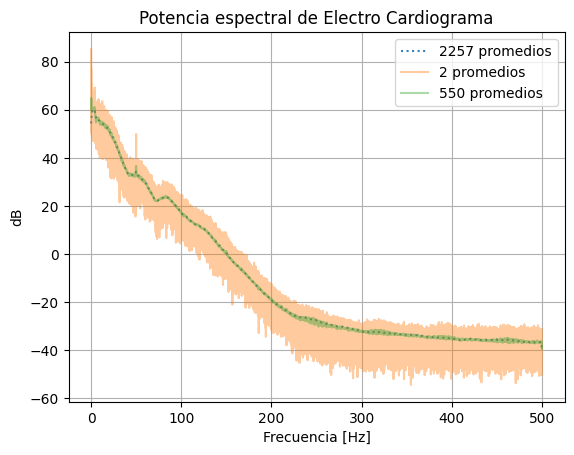

In [24]:
##################
# Lectura de ECG #
##################

fs_ecg = 1000 # Hz

##################
## ECG con ruido
##################

# para listar las variables que hay en el archivo
sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead']
N = len(ecg_one_lead)


f_ecg,Pxx_ecg=sig.welch(ecg_one_lead.flatten(),fs_ecg,window='blackmanharris',nperseg=nperseg)
f_ecg_2,Pxx_ecg_2=sig.welch(ecg_one_lead.flatten(),fs_ecg,window='blackmanharris',nperseg=len(ecg_one_lead)/2)
f_ecg_3,Pxx_ecg_3=sig.welch(ecg_one_lead.flatten(),fs_ecg,window='blackmanharris',nperseg=4096)             

plt.figure()
plt.plot(f_ecg,10*np.log10(Pxx_ecg),label='2257 promedios',alpha=0.9,linestyle=':')
plt.plot(f_ecg_2,10*np.log10(Pxx_ecg_2),label='2 promedios',alpha=0.4)
plt.plot(f_ecg_3,10*np.log10(Pxx_ecg_3),label='550 promedios',alpha=0.4)

plt.grid(True)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('dB')
plt.title('Potencia espectral de Electro Cardiograma')
plt.legend()
plt.show()

La mayoría de la energía está nuevamente concentrada en bajas frecuencias, y luego empieza a caer. El ruido es muy alto para bajos promedios, mientras que para altas no se logra apreciar tanto los picos. El punto medio en 550 parece ser un buen trade off.

# Lectura de pletismografía (PPG)  

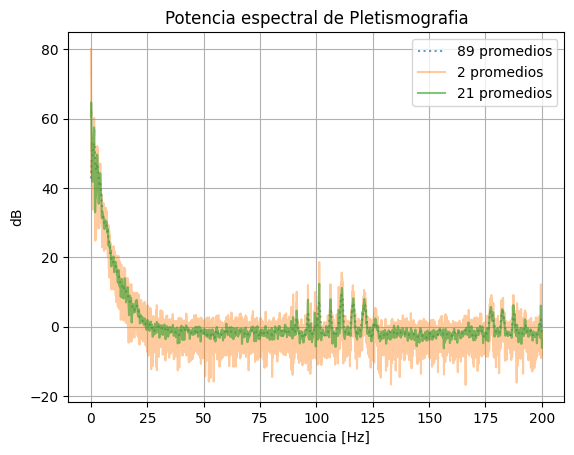

In [23]:
fs_ppg = 400 # Hz

# # Cargar el archivo CSV como un array de NumPy
ppg = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)  # Omitir la cabecera si existe

f_ppg,Pxx_ppg=sig.welch(ppg.flatten(),fs_ppg,window='blackmanharris',nperseg=nperseg)
f_ppg_2,Pxx_ppg_2=sig.welch(ppg.flatten(),fs_ppg,window='blackmanharris',nperseg=len(ppg)/2)
f_ppg_3,Pxx_ppg_3=sig.welch(ppg.flatten(),fs_ppg,window='blackmanharris',nperseg=4096)

plt.figure()
plt.plot(f_ppg,10*np.log10(Pxx_ppg),label='89 promedios',alpha=0.7,linestyle=':')
plt.plot(f_ppg_2,10*np.log10(Pxx_ppg_2),label='2 promedios',alpha=0.4)
plt.plot(f_ppg_3,10*np.log10(Pxx_ppg_3),label='21 promedios',alpha=0.6)

plt.grid(True)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('dB')
plt.title('Potencia espectral de Pletismografia')
plt.legend()
plt.show()


La energía está concentrada a bajas frecuencias aunque existen algunos picos a otras componentes de frecuencia superiores. La relación entre cantidad de promedios y relación precisión/varianza es similar a los dos gráficos anteriores.

#  Ancho de Banda

In [17]:

# Estimacion ancho de banda
potencia_total_la_cucaracha = np.sum(Pxx)
potencia_acumulada_la_cucaracha = np.cumsum(Pxx)

# Busco cuando la energía acumulada alcanza el 95% del total
indice_bw = np.where(potencia_acumulada_la_cucaracha >= 0.95 * potencia_total_la_cucaracha)[0][0]

ancho_de_banda_la_cucaracha = f[indice_bw]

#ECG
potencia_total_ECG=np.sum(Pxx_ecg_3)
potencia_acumulada_ECG=np.cumsum(Pxx_ecg_3)

indice_bw=np.where(potencia_acumulada_ECG>=0.95*potencia_total_ECG)[0][0] 

ancho_de_banda_ecg=f_ecg_3[indice_bw]

#PPG
potencia_total_ppg=np.sum(Pxx_ppg_3)
potencia_acumulada_ppg=np.cumsum(Pxx_ppg_3)

indice_bw=np.where(potencia_acumulada_ppg>=0.95*potencia_total_ppg)[0][0]

ancho_de_banda_ppg=f_ppg_3[indice_bw]

#TABLA
print("-" * 45)
print(f"{'Señal':<25} | {'Ancho de Banda (95%)':<15}")
print("-" * 45)
print(f"{'Audio (La cucaracha)':<25} | {ancho_de_banda_la_cucaracha:>12.2f} Hz")
print(f"{'Electrocardiograma (ECG)':<25} | {ancho_de_banda_ecg:>12.2f} Hz")
print(f"{'Pletismografía (PPG)':<25} | {ancho_de_banda_ppg:>12.2f} Hz")
print("-" * 45)

---------------------------------------------
Señal                     | Ancho de Banda (95%)
---------------------------------------------
Audio (La cucaracha)      |      1536.00 Hz
Electrocardiograma (ECG)  |        22.22 Hz
Pletismografía (PPG)      |         2.83 Hz
---------------------------------------------


# Conclusiones

Se evidenció el compromiso principal al momento de la estimación espectral por medio del método de Welch: Tener muchas subdivisiones del tamaño de la señal (ventanas temporales cortas) baja la resolución frecuencial, por lo que se pierde la capacidad de distinguir componentes que estén muy pegadas en frecuencia, perdiendo información clave de la señal, pero por su parte, hacer pocos promedios genera estimaciones inestables debido a que el ruido se vuelve muy fuerte. La clave del análisis espectral por medio de welch es encontrar un punto medio que permita leer la señal de manera precisa y sin varianza debido al ruido.

La determinación  del ancho de banda es útil para saber a partir de qué punto la señal deja de tener información importante y solo empieza a mostrar ruido. De allí se ve que ambas señales fisiológicas son de muy baja frecuencia, debido a que estas señales nacen de latidos del corazón y circulación de sangre, mientras que la señal de sonido, proveniente de una voz, es de ancho de banda mucho mayor. Esto demuestra por qué los sistemas de audio requieren frecuencias de muestreo muchísimo más altas y mayor capacidad de procesamiento y almacenamiento de datos, mientras que los equipos de monitoreo médico pueden funcionar de manera eficiente digitalizando a unas pocas centenas de muestras por segundo